# 🌿 Cassava Leaf Disease Classification
## Notebook 02: Data Preprocessing and Augmentation

**ML Coursework Project**

---

### Notebook Objectives
1. Create efficient data loading pipeline
2. Implement image preprocessing (resize, normalize)
3. Apply data augmentation techniques
4. Create train/validation split
5. Handle class imbalance with class weights
6. Prepare data generators for training

## 1. Import Libraries

In [1]:
# Core libraries
import os
import numpy as np
import pandas as pd
from pathlib import Path
import json
import pickle

# Image processing
import cv2
from PIL import Image

# PyTorch runtime
import torch
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Progress bar
from tqdm import tqdm

# Warnings
import warnings
warnings.filterwarnings('ignore')

# Check GPU availability
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"Using device: {device}")

print("✅ Libraries imported successfully!")


PyTorch version: 2.11.0+cu128
CUDA Available: True
GPU: NVIDIA GeForce RTX 5060 Laptop GPU
Using device: cuda
✅ Libraries imported successfully!


## 2. Configuration

In [2]:
# Configuration
class Config:
    # Paths
    BASE_PATH = Path('cassava-disease')
    TRAIN_PATH = BASE_PATH / 'train' / 'train'
    TEST_PATH = BASE_PATH / 'test' / 'test'
    OUTPUT_PATH = Path('outputs')
    
    # Image settings
    IMG_SIZE = 224  # Standard size for pre-trained models
    IMG_SHAPE = (IMG_SIZE, IMG_SIZE, 3)
    
    # Training settings
    BATCH_SIZE = 32
    VALIDATION_SPLIT = 0.2
    RANDOM_STATE = 42
    
    # Class mapping
    CLASSES = ['cbb', 'cbsd', 'cgm', 'cmd', 'healthy']
    NUM_CLASSES = len(CLASSES)
    
    # ImageNet normalization (for transfer learning)
    IMAGENET_MEAN = [0.485, 0.456, 0.406]
    IMAGENET_STD = [0.229, 0.224, 0.225]

config = Config()

# Create output directory
config.OUTPUT_PATH.mkdir(exist_ok=True)

print(f"📁 Configuration:")
print(f"   - Image size: {config.IMG_SIZE}x{config.IMG_SIZE}")
print(f"   - Batch size: {config.BATCH_SIZE}")
print(f"   - Validation split: {config.VALIDATION_SPLIT}")
print(f"   - Classes: {config.CLASSES}")

📁 Configuration:
   - Image size: 224x224
   - Batch size: 32
   - Validation split: 0.2
   - Classes: ['cbb', 'cbsd', 'cgm', 'cmd', 'healthy']


## 3. Load Dataset

In [3]:
def load_dataset_info():
    """Load all image paths and labels from the training directory."""
    image_paths = []
    labels = []
    
    for class_idx, class_name in enumerate(config.CLASSES):
        class_path = config.TRAIN_PATH / class_name
        if not class_path.exists():
            print(f"⚠️ Class folder not found: {class_path}")
            continue
        
        for img_file in os.listdir(class_path):
            if img_file.lower().endswith(('.jpg', '.jpeg', '.png')):
                image_paths.append(str(class_path / img_file))
                labels.append(class_idx)
    
    return np.array(image_paths), np.array(labels)

# Load dataset info
print("Loading dataset information...")
image_paths, labels = load_dataset_info()

print(f"\n📊 Dataset loaded:")
print(f"   - Total images: {len(image_paths):,}")
print(f"   - Class distribution:")
for class_idx, class_name in enumerate(config.CLASSES):
    count = np.sum(labels == class_idx)
    print(f"     {class_name}: {count:,} ({count/len(labels)*100:.1f}%)")

Loading dataset information...

📊 Dataset loaded:
   - Total images: 5,656
   - Class distribution:
     cbb: 466 (8.2%)
     cbsd: 1,443 (25.5%)
     cgm: 773 (13.7%)
     cmd: 2,658 (47.0%)
     healthy: 316 (5.6%)


## 4. Train/Validation Split

In [4]:
# Stratified train/validation split
X_train_paths, X_val_paths, y_train, y_val = train_test_split(
    image_paths, 
    labels, 
    test_size=config.VALIDATION_SPLIT,
    stratify=labels,
    random_state=config.RANDOM_STATE
)

print(f"📊 Train/Validation Split:")
print(f"   - Training samples: {len(X_train_paths):,} ({(1-config.VALIDATION_SPLIT)*100:.0f}%)")
print(f"   - Validation samples: {len(X_val_paths):,} ({config.VALIDATION_SPLIT*100:.0f}%)")

# Verify stratification
print(f"\n📊 Stratification check:")
print("   Train distribution:")
for class_idx, class_name in enumerate(config.CLASSES):
    count = np.sum(y_train == class_idx)
    print(f"     {class_name}: {count:,} ({count/len(y_train)*100:.1f}%)")

📊 Train/Validation Split:
   - Training samples: 4,524 (80%)
   - Validation samples: 1,132 (20%)

📊 Stratification check:
   Train distribution:
     cbb: 373 (8.2%)
     cbsd: 1,154 (25.5%)
     cgm: 618 (13.7%)
     cmd: 2,126 (47.0%)
     healthy: 253 (5.6%)


## 5. Compute Class Weights

In [5]:
# Compute class weights to handle imbalance
class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights = dict(enumerate(class_weights_array))

print("📊 Class Weights (for handling imbalance):")
for class_idx, weight in class_weights.items():
    print(f"   {config.CLASSES[class_idx]}: {weight:.4f}")

# Save class weights
with open(config.OUTPUT_PATH / 'class_weights.json', 'w') as f:
    json.dump({config.CLASSES[k]: v for k, v in class_weights.items()}, f, indent=2)
print("\n✅ Class weights saved to outputs/class_weights.json")

📊 Class Weights (for handling imbalance):
   cbb: 2.4257
   cbsd: 0.7841
   cgm: 1.4641
   cmd: 0.4256
   healthy: 3.5763

✅ Class weights saved to outputs/class_weights.json


## 6. Image Preprocessing Functions

In [6]:
def preprocess_image(image_path, target_size=(224, 224)):
    """
    Preprocess a single image.
    
    Steps:
    1. Read image
    2. Convert BGR to RGB
    3. Resize to target size
    4. Normalize to [0, 1]
    
    Parameters:
    -----------
    image_path : str
        Path to the image file
    target_size : tuple
        Target size (height, width)
    
    Returns:
    --------
    numpy.ndarray
        Preprocessed image array
    """
    # Read image
    img = cv2.imread(image_path)
    
    # Convert BGR to RGB
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # Resize
    img = cv2.resize(img, target_size)
    
    # Normalize to [0, 1]
    img = img.astype(np.float32) / 255.0
    
    return img


def apply_imagenet_normalization(img):
    """
    Apply ImageNet normalization for transfer learning.
    
    Formula: (pixel - mean) / std for each channel
    """
    mean = np.array(config.IMAGENET_MEAN)
    std = np.array(config.IMAGENET_STD)
    return (img - mean) / std


print("✅ Preprocessing functions defined")

✅ Preprocessing functions defined


## 7. Data Augmentation

In [7]:
# Data augmentation strategy used by the custom generator below
print("📊 Data Augmentation Configuration:")
print("   Training augmentation:")
print("   - Rotation: +/-30°")
print("   - Horizontal/Vertical flip: Yes")
print("   - Brightness: 80-120%")
print("   - Validation: no augmentation, only normalization")


📊 Data Augmentation Configuration:
   Training augmentation:
   - Rotation: +/-30°
   - Horizontal/Vertical flip: Yes
   - Brightness: 80-120%
   - Validation: no augmentation, only normalization


Visualizing augmentation effects...


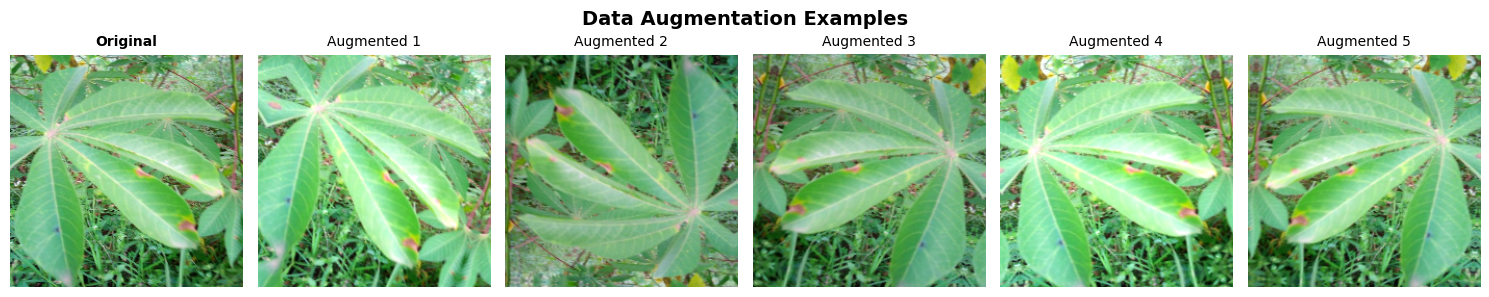

Saved augmentation example for 'cbb'


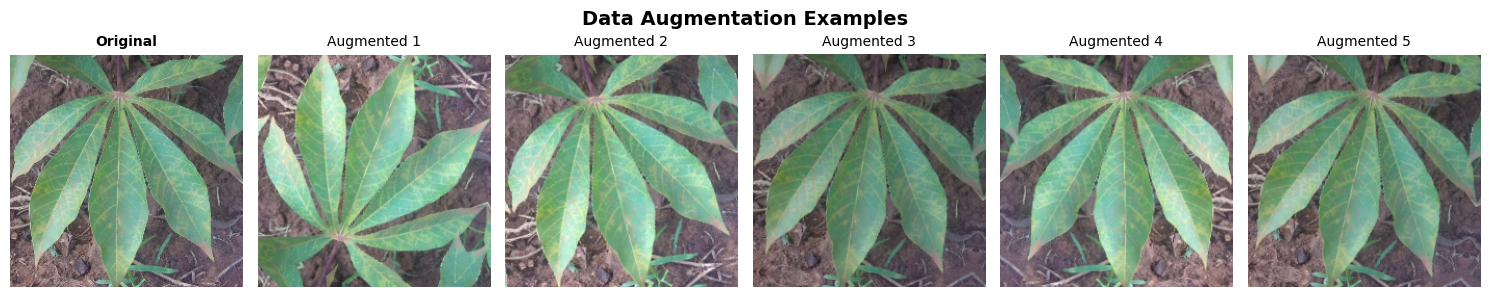

Saved augmentation example for 'cbsd'


In [8]:
# Visualize augmentation effects using the custom augmentation pipeline
def random_augment(img):
    if np.random.random() > 0.5:
        img = cv2.flip(img, 1)
    if np.random.random() > 0.5:
        img = cv2.flip(img, 0)
    angle = np.random.uniform(-30, 30)
    h, w = img.shape[:2]
    matrix = cv2.getRotationMatrix2D((w / 2, h / 2), angle, 1.0)
    img = cv2.warpAffine(img, matrix, (w, h), borderMode=cv2.BORDER_REFLECT)
    factor = np.random.uniform(0.8, 1.2)
    img = np.clip(img * factor, 0, 255).astype(np.uint8)
    return img

def visualize_augmentation(image_path, n_augmented=5):
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (config.IMG_SIZE, config.IMG_SIZE))
    fig, axes = plt.subplots(1, n_augmented + 1, figsize=(15, 3))
    axes[0].imshow(img)
    axes[0].set_title('Original', fontsize=10, fontweight='bold')
    axes[0].axis('off')
    for i in range(n_augmented):
        aug_img = random_augment(img.copy())
        axes[i + 1].imshow(aug_img)
        axes[i + 1].set_title(f'Augmented {i+1}', fontsize=10)
        axes[i + 1].axis('off')
    plt.suptitle('Data Augmentation Examples', fontsize=14, fontweight='bold')
    plt.tight_layout()
    return fig

print("Visualizing augmentation effects...")
for class_name in config.CLASSES[:2]:
    class_path = config.TRAIN_PATH / class_name
    sample_image = list(class_path.glob('*.jpg'))[0]
    fig = visualize_augmentation(str(sample_image))
    plt.savefig(f'outputs/augmentation_{class_name}.png', dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Saved augmentation example for '{class_name}'")


## 8. Create Data Generators

In [9]:
# We use the custom generator (defined below) so the pipeline stays framework-agnostic.
print("📊 Generator Strategy:")
print("   - Using custom NumPy/OpenCV generator")
print("   - Train/validation split comes from train_test_split")
print("   - Compatible with scikit-learn and PyTorch workflows")


📊 Generator Strategy:
   - Using custom NumPy/OpenCV generator
   - Train/validation split comes from train_test_split
   - Compatible with scikit-learn and PyTorch workflows


In [10]:
# Alternative: Create custom data generators using the train/val split

# For more control, we'll create a custom data generator class
class CassavaDataGenerator:
    """
    Custom data generator for Cassava dataset.
    
    Features:
    - Loads images on-the-fly (memory efficient)
    - Applies preprocessing and augmentation
    - Supports class weights
    """
    
    def __init__(self, image_paths, labels, batch_size=32, img_size=224, 
                 augment=False, shuffle=True):
        self.image_paths = image_paths
        self.labels = labels
        self.batch_size = batch_size
        self.img_size = img_size
        self.augment = augment
        self.shuffle = shuffle
        self.indexes = np.arange(len(self.image_paths))
        
        if self.shuffle:
            np.random.shuffle(self.indexes)
    
    def __len__(self):
        return int(np.ceil(len(self.image_paths) / self.batch_size))
    
    def __getitem__(self, idx):
        batch_indexes = self.indexes[idx * self.batch_size:(idx + 1) * self.batch_size]
        batch_paths = [self.image_paths[i] for i in batch_indexes]
        batch_labels = [self.labels[i] for i in batch_indexes]
        
        X = np.array([self._load_and_preprocess(path) for path in batch_paths])
        y = np.eye(config.NUM_CLASSES, dtype=np.float32)[batch_labels]
        
        return X, y
    
    def _load_and_preprocess(self, path):
        # Read image
        img = cv2.imread(path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (self.img_size, self.img_size))
        
        # Apply augmentation if training
        if self.augment:
            img = self._augment(img)
        
        # Normalize to [0, 1]
        img = img.astype(np.float32) / 255.0
        
        return img
    
    def _augment(self, img):
        # Random horizontal flip
        if np.random.random() > 0.5:
            img = cv2.flip(img, 1)
        
        # Random vertical flip
        if np.random.random() > 0.5:
            img = cv2.flip(img, 0)
        
        # Random rotation
        angle = np.random.uniform(-30, 30)
        h, w = img.shape[:2]
        M = cv2.getRotationMatrix2D((w/2, h/2), angle, 1)
        img = cv2.warpAffine(img, M, (w, h), borderMode=cv2.BORDER_REFLECT)
        
        # Random brightness
        factor = np.random.uniform(0.8, 1.2)
        img = np.clip(img * factor, 0, 255).astype(np.uint8)
        
        return img
    
    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indexes)


print("✅ Custom CassavaDataGenerator class defined")

✅ Custom CassavaDataGenerator class defined


In [11]:
# Create training and validation generators
train_gen = CassavaDataGenerator(
    X_train_paths, y_train,
    batch_size=config.BATCH_SIZE,
    img_size=config.IMG_SIZE,
    augment=True,
    shuffle=True
)

val_gen = CassavaDataGenerator(
    X_val_paths, y_val,
    batch_size=config.BATCH_SIZE,
    img_size=config.IMG_SIZE,
    augment=False,
    shuffle=False
)

print(f"📊 Data Generators Created:")
print(f"   Training:")
print(f"     - Samples: {len(X_train_paths):,}")
print(f"     - Batches: {len(train_gen)}")
print(f"     - Augmentation: Enabled")
print(f"   Validation:")
print(f"     - Samples: {len(X_val_paths):,}")
print(f"     - Batches: {len(val_gen)}")
print(f"     - Augmentation: Disabled")

📊 Data Generators Created:
   Training:
     - Samples: 4,524
     - Batches: 142
     - Augmentation: Enabled
   Validation:
     - Samples: 1,132
     - Batches: 36
     - Augmentation: Disabled



📊 Batch verification:
   X_batch shape: (32, 224, 224, 3)
   y_batch shape: (32, 5)
   X_batch dtype: float32
   X_batch range: [0.000, 1.000]


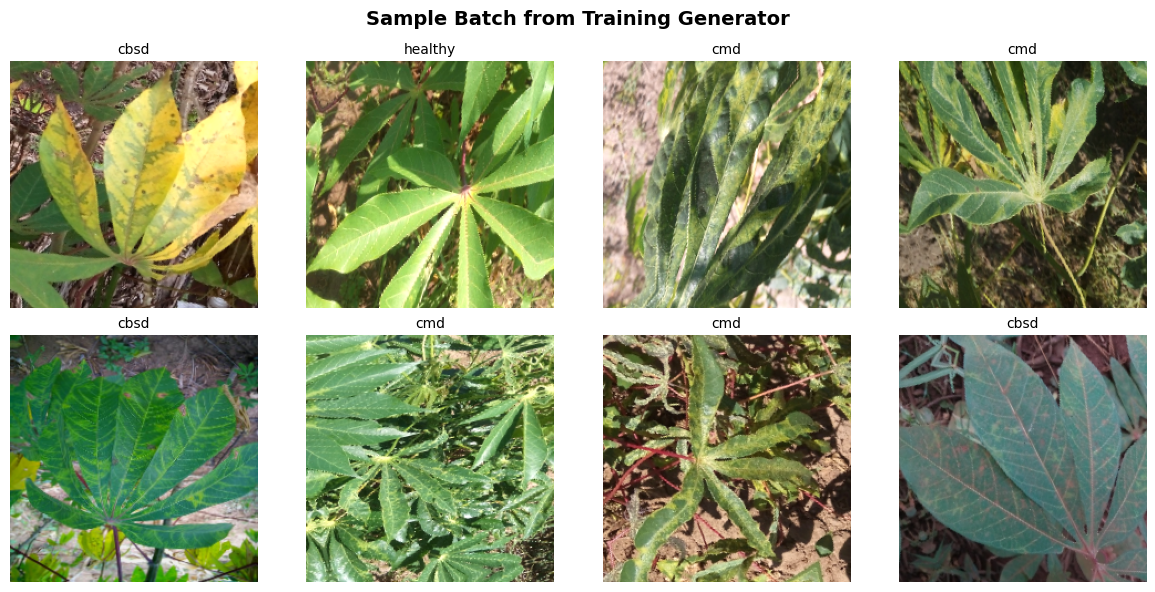


✅ Sample batch saved to outputs/sample_batch.png


In [12]:
# Verify generator output
X_batch, y_batch = train_gen[0]

print(f"\n📊 Batch verification:")
print(f"   X_batch shape: {X_batch.shape}")
print(f"   y_batch shape: {y_batch.shape}")
print(f"   X_batch dtype: {X_batch.dtype}")
print(f"   X_batch range: [{X_batch.min():.3f}, {X_batch.max():.3f}]")

# Visualize a batch
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for i, ax in enumerate(axes.flat):
    if i < len(X_batch):
        ax.imshow(X_batch[i])
        label_idx = np.argmax(y_batch[i])
        ax.set_title(config.CLASSES[label_idx], fontsize=10)
    ax.axis('off')

plt.suptitle('Sample Batch from Training Generator', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/sample_batch.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ Sample batch saved to outputs/sample_batch.png")

## 9. Load and Preprocess All Data (for Traditional ML)

In [13]:
def load_all_images(image_paths, labels, img_size=224, batch_size=100):
    """
    Load all images into memory for traditional ML models.
    Uses batched loading to manage memory.
    
    Note: This is needed for feature extraction with pre-trained CNN,
    which will then be used for traditional ML models.
    """
    n_samples = len(image_paths)
    X = np.zeros((n_samples, img_size, img_size, 3), dtype=np.float32)
    
    print(f"Loading {n_samples:,} images...")
    
    for i in tqdm(range(n_samples)):
        try:
            img = cv2.imread(image_paths[i])
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, (img_size, img_size))
            X[i] = img.astype(np.float32) / 255.0
        except Exception as e:
            print(f"\n⚠️ Error loading {image_paths[i]}: {e}")
            continue
    
    return X, labels

print("\n💡 Note: Full data loading function defined.")
print("   This will be used in the Feature Engineering notebook")
print("   to extract features using pre-trained CNN.")


💡 Note: Full data loading function defined.
   This will be used in the Feature Engineering notebook
   to extract features using pre-trained CNN.


## 10. Save Preprocessing Configuration

In [14]:
# Save all necessary information for next notebooks
preprocessing_config = {
    'img_size': config.IMG_SIZE,
    'batch_size': config.BATCH_SIZE,
    'validation_split': config.VALIDATION_SPLIT,
    'classes': config.CLASSES,
    'num_classes': config.NUM_CLASSES,
    'n_train': len(X_train_paths),
    'n_val': len(X_val_paths),
    'class_weights': {k: float(v) for k, v in class_weights.items()},
    'imagenet_mean': config.IMAGENET_MEAN,
    'imagenet_std': config.IMAGENET_STD
}

with open(config.OUTPUT_PATH / 'preprocessing_config.json', 'w') as f:
    json.dump(preprocessing_config, f, indent=2)

print("✅ Preprocessing configuration saved to outputs/preprocessing_config.json")

# Save train/val split paths for reproducibility
split_data = {
    'X_train_paths': X_train_paths.tolist(),
    'X_val_paths': X_val_paths.tolist(),
    'y_train': y_train.tolist(),
    'y_val': y_val.tolist()
}

with open(config.OUTPUT_PATH / 'train_val_split.pkl', 'wb') as f:
    pickle.dump(split_data, f)

print("✅ Train/Val split saved to outputs/train_val_split.pkl")

✅ Preprocessing configuration saved to outputs/preprocessing_config.json
✅ Train/Val split saved to outputs/train_val_split.pkl


## 11. Summary

In [15]:
print("="*60)
print("📊 DATA PREPROCESSING SUMMARY")
print("="*60)

print(f"\n🔹 Dataset Split:")
print(f"   - Training: {len(X_train_paths):,} images (80%)")
print(f"   - Validation: {len(X_val_paths):,} images (20%)")

print(f"\n🔹 Preprocessing Steps:")
print(f"   1. Resize to {config.IMG_SIZE}x{config.IMG_SIZE} pixels")
print(f"   2. Normalize to [0, 1] range")
print(f"   3. Data augmentation (training only):")
print(f"      - Rotation: ±30°")
print(f"      - Flip: Horizontal & Vertical")
print(f"      - Zoom: ±20%")
print(f"      - Brightness: 80-120%")

print(f"\n🔹 Class Weights (for imbalance):")
for class_idx, weight in class_weights.items():
    print(f"   {config.CLASSES[class_idx]}: {weight:.4f}")

print(f"\n🔹 Files Saved:")
print(f"   - outputs/preprocessing_config.json")
print(f"   - outputs/train_val_split.pkl")
print(f"   - outputs/class_weights.json")
print(f"   - outputs/augmentation_*.png")
print(f"   - outputs/sample_batch.png")

print("\n" + "="*60)

📊 DATA PREPROCESSING SUMMARY

🔹 Dataset Split:
   - Training: 4,524 images (80%)
   - Validation: 1,132 images (20%)

🔹 Preprocessing Steps:
   1. Resize to 224x224 pixels
   2. Normalize to [0, 1] range
   3. Data augmentation (training only):
      - Rotation: ±30°
      - Flip: Horizontal & Vertical
      - Zoom: ±20%
      - Brightness: 80-120%

🔹 Class Weights (for imbalance):
   cbb: 2.4257
   cbsd: 0.7841
   cgm: 1.4641
   cmd: 0.4256
   healthy: 3.5763

🔹 Files Saved:
   - outputs/preprocessing_config.json
   - outputs/train_val_split.pkl
   - outputs/class_weights.json
   - outputs/augmentation_*.png
   - outputs/sample_batch.png



---
## 📌 Next Steps

Proceed to **Notebook 03: Feature Engineering** to:
1. Extract deep features using pre-trained CNN (VGG16/ResNet50)
2. Apply PCA for dimensionality reduction
3. Visualize features using t-SNE

---
*End of Notebook 02*